In [1]:
import numpy as np
import scipy
import scipy.sparse
import scipy.sparse.linalg
import matplotlib
import matplotlib.cm
import matplotlib.pyplot as plt

import cnetwork
from cnetwork import MagmaChamber, GlobalSystemThreshold

In [11]:
# Random distribution
np.random.seed(0)

In [12]:
# Set default properties
default_props = dict(
  t_b = 1e11,
  t_d = 5e10,
  K_crust = 10e9,
  G_crust = 10e9,
  K_f = 10e9,
  rho0 = 2500,
  r_hydr = 5,
  mu0 = 1e6,
  R_min = 500,
  R_max = 500,
  N_chamber = 25,
  x_scale = 40e3,
  z_scale = 40e3,
  mass_in_rate = 3.0,
  p_erupt = 5e6,
  dpdx_crit = 1e3,
  dpdx_threshold_scale = 0.0,
  mu_erupt = 1e5,
  r_conduit_erupt = 25,
)

In [15]:
def generate_and_save_run(id:str, props, seed=None):

  if seed is not None:
    np.random.seed(seed)

  t_b = props["t_b"]
  t_d = props["t_d"]
  K_crust = props["K_crust"]
  G_crust = props["G_crust"]
  K_f = props["K_f"]
  r_hydr = props["r_hydr"]
  mu0 = props["mu0"]
  R_min = props["R_min"]
  R_max = props["R_max"]
  N_chamber = props["N_chamber"]
  x_scale = props["x_scale"]
  z_scale = props["z_scale"]

  # Uniformly randomly distribution volume
  V_min = (4/3)*np.pi*R_min**3
  V_max = (4/3)*np.pi*R_max**3
  # List generation of chamber characteristics
  x_nodes = x_scale * np.random.rand(N_chamber)
  y_nodes = 0.0 * np.random.rand(N_chamber)
  z_nodes = np.linspace(0.0, z_scale, N_chamber)
  # Fix bottom and top nodes
  z_nodes[0] = 0.0
  z_nodes[-1] = z_scale
  x_nodes[0] = 0.5 * x_scale
  x_nodes[-1] = 0.5 * x_scale

  V_nodes = V_min + (V_max - V_min) * np.random.rand(N_chamber)

  list_nodes = [MagmaChamber(
                    x=x,
                    y=y,
                    z=z,
                    p_setting=0.0,
                    p0=0,
                    T_setting=1200,
                    V_setting=V)
              for (x,y,z,V) in zip(x_nodes, y_nodes, z_nodes, V_nodes)]

  # Set up for timestepping later
  global_sys = GlobalSystemThreshold(list_nodes, t_b, t_d, K_crust, G_crust,
                                    r_hydr=r_hydr, mu0=mu0, 
                                    rho0=2500, K_f=K_f, Nr=50,
                                    dpdx_crit=props["dpdx_crit"],
                                    dpdx_threshold_scale=props["dpdx_threshold_scale"],#1e2,
                                    R_outer_ratio=20, # numerical R(infty) / R0
                                    max_edge_dist=np.inf)

  # Source term due to mass injection at node 0
  f_inj = global_sys.create_single_mass_injection_source(props["mass_in_rate"])
  # Source term due to eruption at node -1
  f_erupt = global_sys.create_eruption_source(p_erupt=props["p_erupt"],
                                              mu_erupt=props["mu_erupt"],
                                              r_conduit=props["r_conduit_erupt"])

  # Primary simulation
  t_vec = np.linspace(0, 1e11, 16000)
  print(f"Starting simulation with id {id}.")
  q_out, m_erupted_out = global_sys.simulation(global_sys.q0, t_vec, f_inj, f_erupt)

  # Save output
  print(f"Saving simulation to npz file ``output_{id}''.")

  np.savez_compressed(f"output_{id}", q_out=q_out, m_erupted_out=m_erupted_out, props=props)


In [ ]:
generate_and_save_run(0, default_props, seed=0)

In [19]:
4.0**np.arange(-2,3)

array([ 0.0625,  0.25  ,  1.    ,  4.    , 16.    ])

In [30]:
_X = 9
f"{_X:03d}"

'009'

In [ ]:
# Series A: t_d and dpdx_crit
t_d_range = 5e10 * 4.0**np.arange(-2,3)
dpdx_crit_range = 1e3 * 4.0**np.arange(-2,3)
mg_t_d, mg_dpdx_crit = np.meshgrid(t_d_range, dpdx_crit_range)

for i, (t_d, dpdx_crit) in enumerate(zip(mg_t_d.ravel(), mg_dpdx_crit.ravel())):
  props = default_props.copy()
  props["t_d"] = t_d
  props["t_b"] = t_d
  props["dpdx_crit"] = dpdx_crit
  # print(f"A{i:04d}")
  generate_and_save_run(f"A{i:04d}", props, seed=0)

Starting simulation with id A0000.
Saving simulation to npz file ``output_A0000''.
Starting simulation with id A0001.
Saving simulation to npz file ``output_A0001''.
Starting simulation with id A0002.
Saving simulation to npz file ``output_A0002''.
Starting simulation with id A0003.
Saving simulation to npz file ``output_A0003''.
Starting simulation with id A0004.
Saving simulation to npz file ``output_A0004''.
Starting simulation with id A0005.
Saving simulation to npz file ``output_A0005''.
Starting simulation with id A0006.
Saving simulation to npz file ``output_A0006''.
Starting simulation with id A0007.
Saving simulation to npz file ``output_A0007''.
Starting simulation with id A0008.
Saving simulation to npz file ``output_A0008''.
Starting simulation with id A0009.
Saving simulation to npz file ``output_A0009''.
Starting simulation with id A0010.
Saving simulation to npz file ``output_A0010''.
Starting simulation with id A0011.
Saving simulation to npz file ``output_A0011''.
Star

In [183]:
t_d_range = 5e10 * 2.0**np.arange(-6,7)
dpdx_crit_range = 4e3 * 4.0**np.arange(-6,1)
mg_t_d, mg_dpdx_crit = np.meshgrid(t_d_range, dpdx_crit_range)
mg_t_d.shape

(7, 13)

In [ ]:
# Series A2: t_d and dpdx_crit redone
t_d_range = 5e10 * 2.0**np.arange(-5,7)
dpdx_crit_range = 4e3 * 4.0**np.arange(-7,1)
mg_t_d, mg_dpdx_crit = np.meshgrid(t_d_range, dpdx_crit_range)

for i, (t_d, dpdx_crit) in enumerate(zip(mg_t_d.ravel(), mg_dpdx_crit.ravel())):
  props = default_props.copy()
  props["t_d"] = t_d
  props["t_b"] = t_d
  props["dpdx_crit"] = dpdx_crit
  generate_and_save_run(f"A2{i:04d}", props, seed=0)

Starting simulation with id A20000.


KeyboardInterrupt: 

In [33]:
# Series B: K_f as an exsolved-volatile proxy
K_f_range = 10e9 * 4.0**np.arange(-4,1)

for i, K_f in enumerate(K_f_range):
  props = default_props.copy()
  props["K_f"] = K_f
  generate_and_save_run(f"B{i:04d}", props, seed=0)

Starting simulation with id B0000.
Saving simulation to npz file ``output_B0000''.
Starting simulation with id B0001.
Saving simulation to npz file ``output_B0001''.
Starting simulation with id B0002.
Saving simulation to npz file ``output_B0002''.
Starting simulation with id B0003.
Saving simulation to npz file ``output_B0003''.
Starting simulation with id B0004.
Saving simulation to npz file ``output_B0004''.


#### Read and reduce: Series A

In [37]:
out = np.load("output_A0000.npz")
list(out.keys())

['q_out', 'm_erupted_out', 'props']

In [41]:
out["m_erupted_out"]

array([0., 0., 0., ..., 0., 0., 0.])

In [42]:
tracks = [None for i in range(25)]
for i in range(25):
  out = np.load(f"output_A{i:04d}.npz")
  tracks[i] = out["m_erupted_out"]


In [45]:
np.array(tracks).shape

(25, 16000)

$$
De = \frac{t_\mathrm{inj}}{t_\mathrm{d}}
= \frac{1}{t_\mathrm{d}} \frac{m_\mathrm{chamber}}{\dot{m}_\mathrm{inj}}
$$

In [73]:
# Compute initial mass of a chamber
m0 = (4*np.pi/3) * default_props["R_max"] ** 3 * default_props["rho0"]
mdot_inj = default_props["mass_in_rate"]

De = m0 / mdot_inj / mg_t_d

m_tot = default_props["mass_in_rate"] * t_vec[-1]

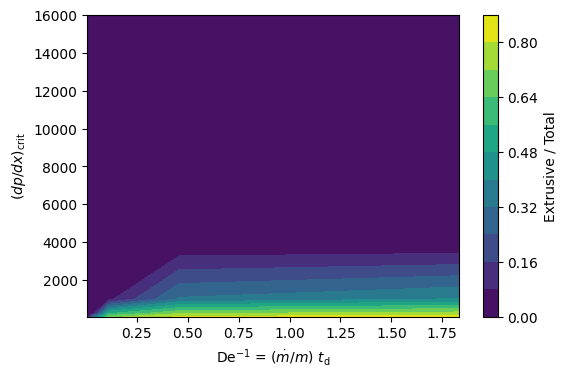

In [80]:
plt.figure(dpi=100)
m_final = np.reshape(np.array(tracks)[:,-1], mg_t_d.shape)
plt.contourf(1/De, mg_dpdx_crit, m_final / m_tot,
             levels=10)
plt.xlabel("$\mathrm{De}^{-1}$ = $(\dot{m} / m)~t_\mathrm{d}$")
plt.ylabel("$(dp/dx)_\mathrm{crit}$")
plt.colorbar(label="Extrusive / Total")

Text(0, 0.5, 'Extrusive / Total at final time')

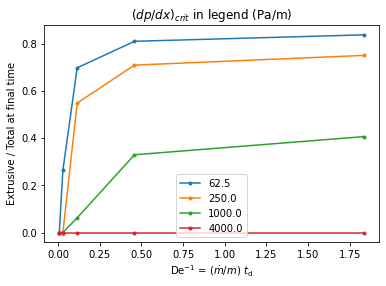

In [108]:
for i in range(4):
  plt.plot(1/De[i,:], m_final[i,:] / m_tot, '.-', label=f"{mg_dpdx_crit[i,0]}")

plt.title(f"$(dp/dx)_{{crit}}$ in legend (Pa/m)")
plt.legend()
plt.xlabel("$\mathrm{De}^{-1}$ = $(\dot{m} / m)~t_\mathrm{d}$")
plt.ylabel("Extrusive / Total at final time")

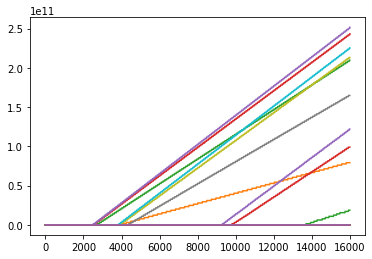

In [70]:
plt.plot(np.array(tracks).T);

Text(0, 0.5, 'Inter-eruption period ($10^9$ s)')

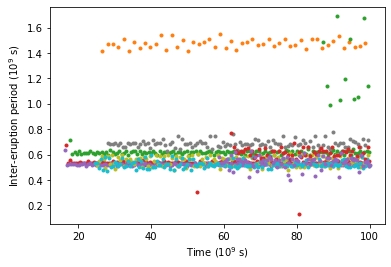

In [159]:
# Edge detection

t_cell = 0.5 * (t_vec[:-1] + t_vec[1:])
dt_vec = t_vec[1:] - t_vec[:-1]

grads = np.diff(np.array(tracks), axis=1)

avg_period = [np.inf for i in range(grads.shape[0])]
onset_times = [np.inf for i in range(grads.shape[0])]

for i in range(grads.shape[0]):

  t_idx_eruption = np.where(np.abs(grads[i,:]) > 0.001)

  intereruptions = np.diff(t_cell[t_idx_eruption])

  plt.plot(t_cell[t_idx_eruption][1:] / 1e9, intereruptions / 1e9, '.')
# plt.xlabel("Eruption count")
# plt.ylabel("Time $\Delta t$ since last eruption ($10^9$ s)")
# ax2y = plt.gca().secondary_yaxis('right', functions=(
#   lambda t: t * 1e9 / (dt_vec[0]),
#   lambda tau: tau * dt_vec[0] / 1e9))
# ax2y.set_ylabel('$\Delta t/dt$', fontsize=14)

  if intereruptions.size > 0:
    avg_period[i] = np.mean(intereruptions)
  if t_idx_eruption[0].size > 0:
    onset_times[i] = t_cell[t_idx_eruption[0][0]]

plt.xlabel("Time ($10^9$ s)")
plt.ylabel("Inter-eruption period ($10^9$ s)")

Text(0, 0.5, 'Inter-eruption interval ($10^9$ s)')

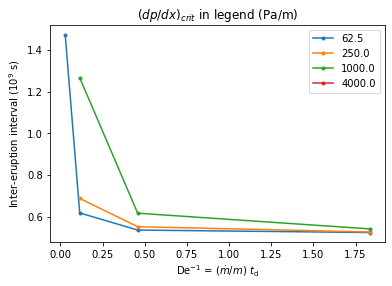

In [ ]:
for i in range(4):
  plt.plot(1/De[i,:], np.reshape(avg_period, De.shape)[i,:] / 1e9,
  '.-', label=f"{mg_dpdx_crit[i,0]}")

plt.title(f"$(dp/dx)_{{crit}}$ in legend (Pa/m)")
plt.legend()
plt.xlabel("$\mathrm{De}^{-1}$ = $(\dot{m} / m)~t_\mathrm{d}$")
plt.ylabel("Inter-eruption interval ($10^9$ s)")

Text(0, 0.5, 'Time to first eruption ($10^9$ s)')

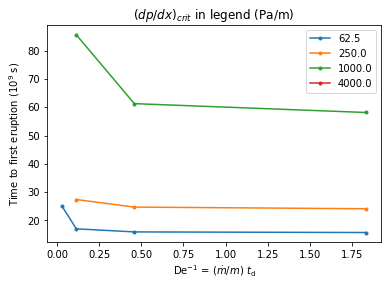

In [170]:
for i in range(4):
  plt.plot(1/De[i,:], np.reshape(onset_times, De.shape)[i,:] / 1e9,
  '.-', label=f"{mg_dpdx_crit[i,0]}")

plt.title(f"$(dp/dx)_{{crit}}$ in legend (Pa/m)")
plt.legend()
plt.xlabel("$\mathrm{De}^{-1}$ = $(\dot{m} / m)~t_\mathrm{d}$")
plt.ylabel("Time to first eruption ($10^9$ s)")

#### Read and reduce: Series B

In [174]:
tracksB = [None for i in range(5)]
for i in range(5):
  out = np.load(f"output_B{i:04d}.npz")
  tracksB[i] = out["m_erupted_out"]


In [ ]:
np.array(tracksB).max()

0.0

In [177]:
out["props"]

ValueError: Object arrays cannot be loaded when allow_pickle=False